In [22]:
import os
import pandas as pd
import numpy as np 
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

In [23]:
dirpath = os.getcwd()
features_path = r"data\gmfeature_table.csv"
data_path = r"C:\Users\marie\rep_codes\udder_project\udder_analysis\long_format_df"
plot_dir = r"C:\Users\marie\rep_codes\udder_project\paper\revision_B\plots"

color_dict = {'lf': 'cyan', 'rf': 'skyblue', 'lb': 'royalblue', 'rb': 'dodgerblue', 'front':'cyan', 
             'right': 'skyblue', 'left': 'royalblue', 'back': 'dodgerblue', 'udder': 'plum'}

tick_map = {"udder":"udder", "lf": "left\nfront", "rf":"right\nfront", "lb": "left\nrear", "rb":"right\nrear", "right":"right", "left":"left", "front": "front", "back":"rear"}

In [24]:
data = pd.read_csv(features_path)

In [25]:
data

,cow,udder_vol,lf_vol,rf_vol,lb_vol,rb_vol,udder_sarea,lf_sarea,rf_sarea,lb_sarea,...,lb_circ,lb_exc,rb_peri,rb_area,rb_circ,rb_exc,lf_len,rf_len,lb_len,rb_len
0,627,6.697424,2.069808,2.295823,0.668200,0.891530,2201.760765,668.536848,714.158081,393.106133,...,0.763152,0.538623,NaN,NaN,0.710039,0.601773,38.580677,41.363481,42.063080,36.517138
1,729,NaN,5.079568,4.364155,0.789035,0.898031,NaN,NaN,1002.755696,262.746586,...,0.671191,0.574017,423.557395,10434.0,0.738175,0.667560,NaN,60.826328,47.845290,35.957032
2,764,6.316109,1.788540,2.241100,0.752663,0.685146,NaN,825.074567,901.399146,567.414139,...,0.644892,0.624028,452.268073,9417.0,0.581946,0.735450,43.875716,44.013406,37.066922,37.681559
3,778,7.745594,NaN,4.014487,0.728581,1.250785,2325.464545,NaN,920.667513,279.629294,...,0.682084,0.328415,509.717821,12203.0,0.576439,0.705144,NaN,58.008059,38.642793,NaN
4,808,7.229062,1.420988,3.074876,0.915043,NaN,2201.687426,405.515521,853.636846,383.161900,...,0.671683,0.425407,586.859956,NaN,0.620503,0.753314,28.795623,50.525514,42.050397,41.907357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,1486,5.378144,1.734115,1.861548,0.768159,0.702433,1964.898450,521.314016,589.685346,475.684154,...,NaN,0.785654,496.498521,11302.0,0.572537,0.778734,37.961439,37.554606,27.339605,23.264238
129,1487,8.376260,5.059448,3.538225,0.712471,0.503287,1788.671257,869.119892,720.359164,208.901041,...,0.676632,0.791993,354.205627,5754.5,0.602927,0.738296,42.302186,51.276823,26.069107,NaN
130,1495,5.783034,1.668636,3.162655,0.557299,0.537761,1910.238056,434.406296,775.294209,346.581440,...,NaN,0.727476,514.640656,10016.5,NaN,0.689949,31.150010,44.635441,27.101730,29.439392
131,1501,7.486284,2.142604,4.278479,0.523835,0.720675,1688.992494,433.107657,923.958614,210.824871,...,0.695512,0.658773,292.710678,5349.0,NaN,0.620216,47.620275,43.362852,37.554216,35.086378


In [26]:
def list_columns(df, keyword):
    column_list = [col for col in df.columns if keyword in col]
    return column_list

def melt_frame(df, cols):
    selected_df = df[cols]
    # melted_df = pd.melt(df, id_vars=['cow', 'frame'], value_vars=cols)
    melted_df = pd.melt(df, id_vars=['cow'], value_vars=cols)
    return melted_df

def subset_df(df, keyword):
    kkword = '_' + keyword
    col = list_columns(df, keyword)
    melted_df = melt_frame(df, col)
    melted_df["variable"] = [val.replace(kkword, "") for val in melted_df["variable"]]
    return melted_df
    
def box_fig(df, keyword, xlab, ylab, frac =1):
    kkword = '_' + keyword
    cols = list_columns(df, kkword)
    melted_df = melt_frame(df, cols)
    melted_df["variable"] = [tick_map[val.replace(kkword, "")] for val in melted_df["variable"]]
    melted_df2 = melted_df[~melted_df.variable.isna()]
    group_df = melted_df2
    # group_df = melted_df.drop(["frame"], axis = 1).groupby(["cow", "variable"]).agg(["mean", "median"]).reset_index()
    # group_df.columns = [c[1] if len(c[1])>0 else c[0] for c in group_df.columns]
    fig = sns.boxplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
    # fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    # fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
    return fig


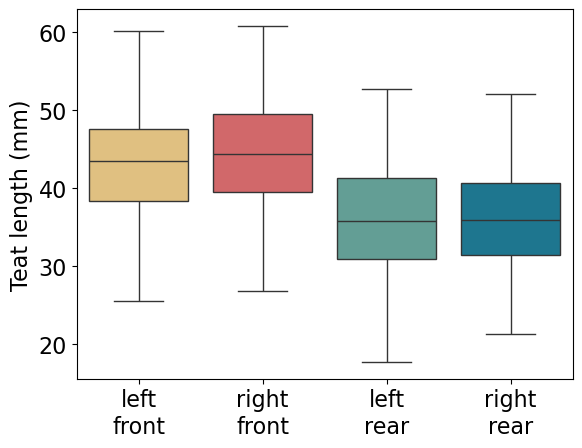

In [27]:

#create your own color array 
# my_colors = ["#666666",'#999999', "#016064",'#93D0C1'] 
my_colors = [ "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "len", "", "Teat length (mm)")

plt.savefig(os.path.join(plot_dir,"teat_len_bplot.png"),bbox_inches='tight')

In [28]:
df2 = subset_df(data, "len")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,122,122
lf,114,114
rb,114,114
rf,115,115


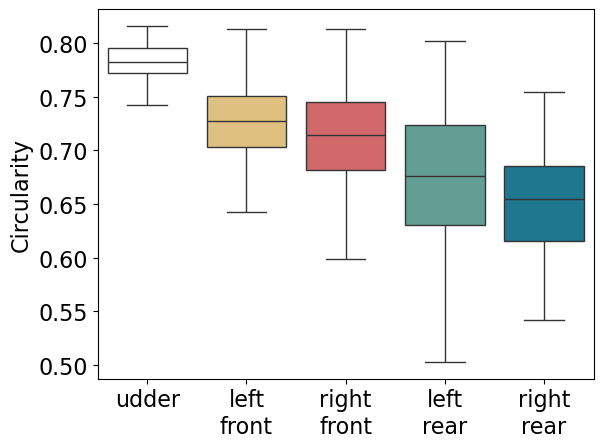

In [29]:
#create your own color array 
# my_colors = ["white","#666666",'#999999', "#016064",'#93D0C1'] 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2']   
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "circ", "", "Circularity")
plt.savefig(os.path.join(plot_dir, "circ_bplot.png"),bbox_inches='tight')

In [30]:
df2 = subset_df(data, "circ")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,121,121
lf,115,115
rb,121,121
rf,120,120
udder,116,116


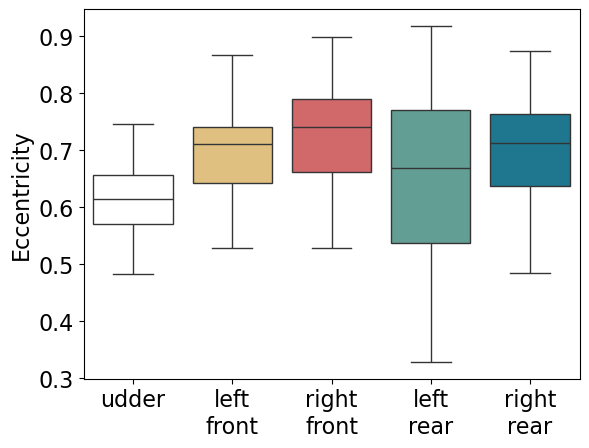

In [31]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "exc", "", "Eccentricity")
plt.savefig(os.path.join(plot_dir, "ecc_bplot.png"),bbox_inches='tight')

In [32]:
df2 = subset_df(data, "exc")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg("count")

,cow,value
variable,,
lb,128,128
lf,113,113
rb,120,120
rf,122,122
udder,119,119


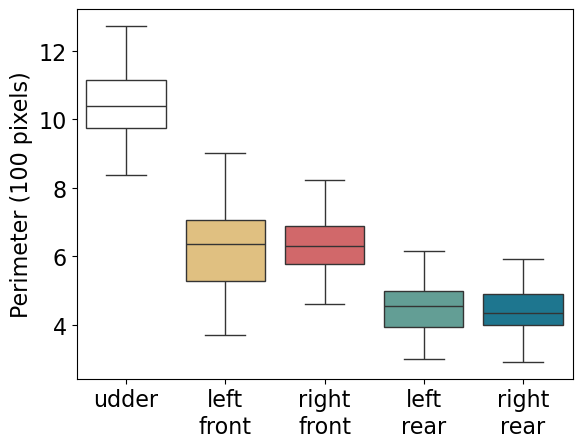

In [33]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2']  

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
fig = plt.figure(figsize=(6.4, 4.8))
box_fig(data, "peri", "", "Perimeter (100 pixels)", 100)
plt.savefig(os.path.join(plot_dir, "peri_bplot.png"),bbox_inches='tight')

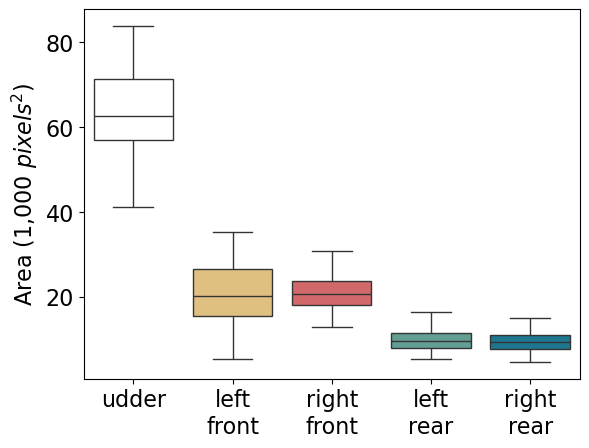

In [48]:
#create your own color array 
my_colors = ["white", "#f0c571", '#e25759', "#59a89c", '#0b81a2'] 

# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "area", "", "Area (1,000 $pixels^2$)", 1000)
plt.savefig(os.path.join(plot_dir, "area_bplot.png"),bbox_inches='tight')

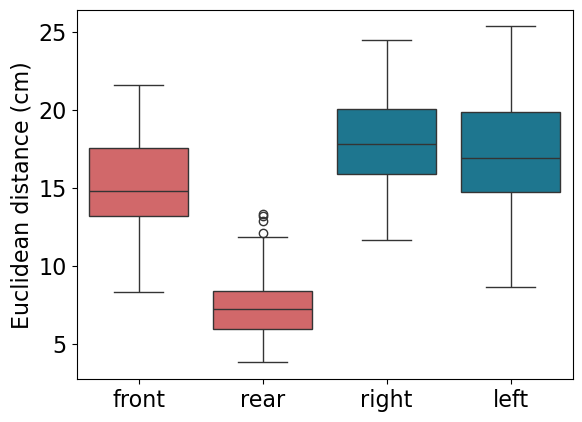

In [49]:
#create your own color array 
# my_colors = ['#999999', '#999999',  
#              "#016064", "#016064"] 
my_colors = ['#e25759', '#e25759','#0b81a2', '#0b81a2'] 
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "eu", "", "Euclidean distance (cm)")
plt.savefig(os.path.join(plot_dir, "eu_bplot.png"),bbox_inches='tight')

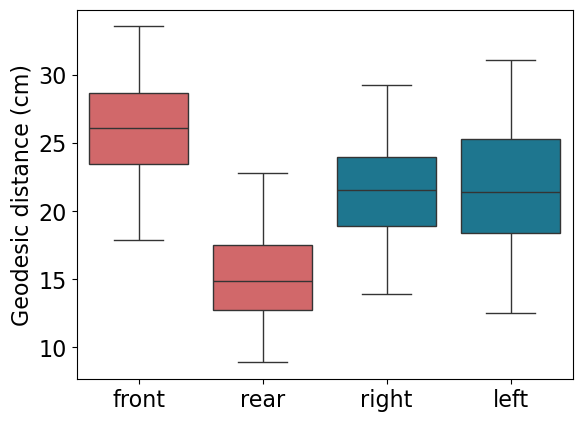

In [50]:
#create your own color array 
my_colors = ['#e25759', '#e25759','#0b81a2', '#0b81a2'] 
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "gd", "", "Geodesic distance (cm)")
plt.savefig(os.path.join(plot_dir, "gd_bplot.png"),bbox_inches='tight')

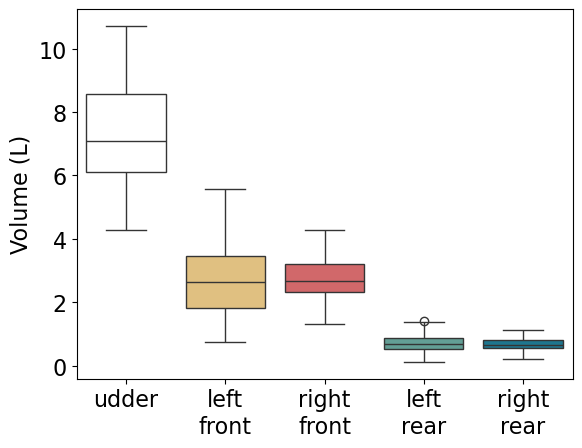

In [51]:
#create your own color array 
my_colors = ["white","#f0c571", '#e25759', "#59a89c", '#0b81a2']  
  
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "vol", "", "Volume (L)")
plt.savefig(os.path.join(plot_dir,"vol_bplot.png"),bbox_inches='tight')
# plt.savefig(os.path.join(plot_dir, "vol_bplot.png"),bbox_inches='tight')

In [52]:
df2 = subset_df(data, "vol")
df2 = df2[~np.isnan(df2.value)]
df2.groupby("variable").agg(
    mean=('value', np.mean),
    count=('value', "count"),
    std_=('value', np.std))

C:\Users\marie\AppData\Local\Temp\ipykernel_2576\422529017.py:3: FutureWarning:

The provided callable <function mean at 0x000002B907136840> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marie\AppData\Local\Temp\ipykernel_2576\422529017.py:3: FutureWarning:

The provided callable <function std at 0x000002B907136980> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.



,mean,count,std_
variable,,,
lb,0.733839,79,0.269753
lf,2.771761,85,1.238112
rb,0.667992,78,0.200094
rf,2.765546,84,0.693997
udder,7.275372,85,1.594464


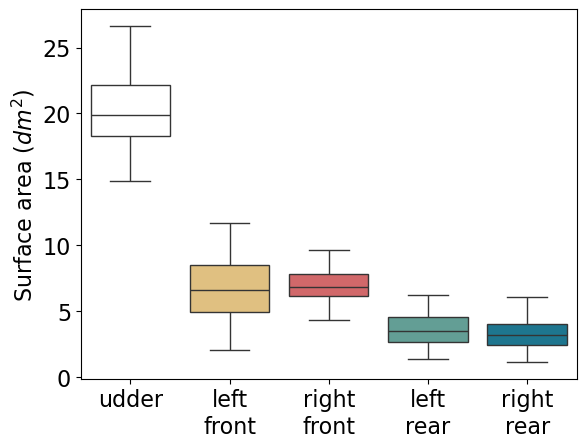

In [53]:
#create your own color array 
my_colors = ["white","#f0c571", '#e25759', "#59a89c", '#0b81a2']
# add color array to set_palette 
# function of seaborn 
sns.set_palette( my_colors ) 
box_fig(data, "sarea", "", "Surface area $(dm^2)$", 100)
plt.savefig(os.path.join(plot_dir, "sarea_bplot.png"),bbox_inches='tight')

In [54]:
merged = pd.read_csv(os.path.join(data_path, "lactation_features.csv"))

Text(0, 0.5, 'ylab')

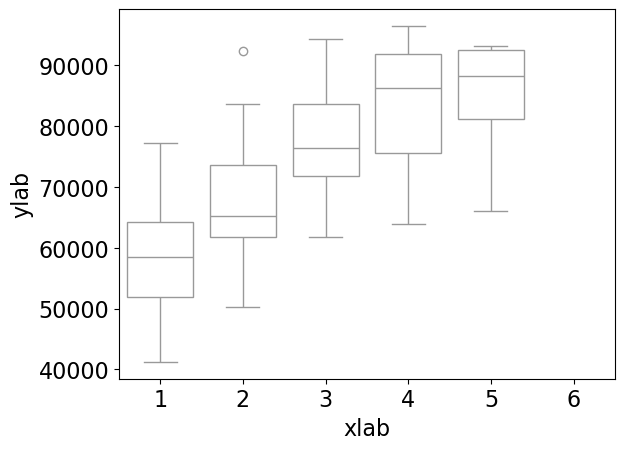

In [55]:
fig = sns.boxplot(y = merged['area_udder'], x = merged['lactation'])
# fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
plt.xlabel("xlab")
plt.ylabel("ylab")

NameError: name 'xlab' is not defined

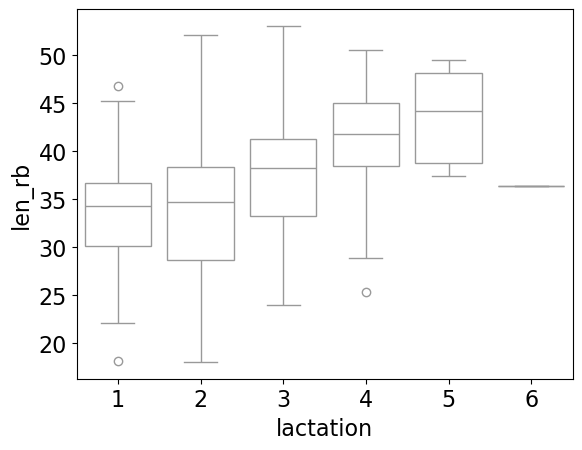

In [56]:
fig = sns.boxplot(y = merged['len_rb'], x = merged['lactation'])
# fig = sns.violinplot(y = group_df["value"]/frac, x = group_df["variable"], hue = group_df["variable"])
plt.xlabel(xlab)
plt.ylabel(ylab)